# 01 — Exploration & DataViz (Rendu 1)

Ce notebook reprend l'exploration des données en **réutilisant les modules du projet** (`src/`).
Il n'y a aucune duplication de logique : le notebook sert de **vitrine narrative** par-dessus le code propre.

Pré-requis : avoir collecté les données (`python -m src.ingestion.run_ingestion`).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))  # rendre `src` importable
%matplotlib inline
import pandas as pd
from scipy import stats
from IPython.display import Image, display

from src.features.target import compute_virality_target
from src.features.build_features import parse_duration_seconds
from src.features import eda

## 1. Chargement & variable cible

In [2]:
df = pd.read_csv('../data/raw/competitors/videos.csv')
df = compute_virality_target(df)          # ajoute views_per_day, virality_score
df['duration_seconds'] = df['duration_iso'].apply(parse_duration_seconds)
print('Volumétrie :', df.shape)
df[['title', 'category', 'language', 'family', 'view_count', 'virality_score']].head()

Volumétrie : (476, 23)


,title,category,language,family,view_count,virality_score
0,Devine les 48 MAILLOTS de la Coupe du Monde 20...,QUIZ_DATAWORLD,FR,DEVINE,9315,-0.037118
1,Connais-tu vraiment la COUPE DU MONDE 2026...?...,QUIZ_FOOT,FR,NaN,79102,0.643786
2,Devine 100 joueurs de football en 3 secondes |...,QUIZ_BASKET,FR,DEVINE,2181050,1.303758
3,Devine le CLUB de FOOTBALL en 3 SECONDES...! ✅...,QUIZ_FOOT,FR,DEVINE,978713,0.448715
4,Le QUIZ FOOT le PLUS DUR ! (99% IMPOSSIBLE) Ft...,QUIZ_FOOT,FR,NaN,70122,-0.630104


## 2. Profil / volumétrie / valeurs manquantes

In [3]:
prof = eda.profile(df)
print('Par langue   :', prof['by_language'])
print('Par catégorie:', prof['by_category'])
print('Par famille  :', prof['by_family'])
print('NA > 0       :', {k: v for k, v in prof['na_rate'].items() if v > 0})

Par langue   : {'EN': 290, 'FR': 186}
Par catégorie: {'QUIZ_DATAWORLD': 84, 'QUIZ_OTAKU': 78, 'QUIZ_KPOP': 71, 'QUIZ_FOOT': 66, 'QUIZ_RELIGION': 64, 'QUIZ_GLOBAL': 58, 'QUIZ_BASKET': 55}
Par famille  : {'DEVINE': 238, nan: 191, 'REBUS_EMOJIS': 23, 'TU_PREFERES': 19, 'VRAI_FAUX': 3, 'TROUVER_INTRUS': 2}
NA > 0       : {'description': 0.038, 'like_count': 0.017, 'family': 0.401, 'family_group': 0.401}


## 3. Visualisations (les figures du Rendu 1)

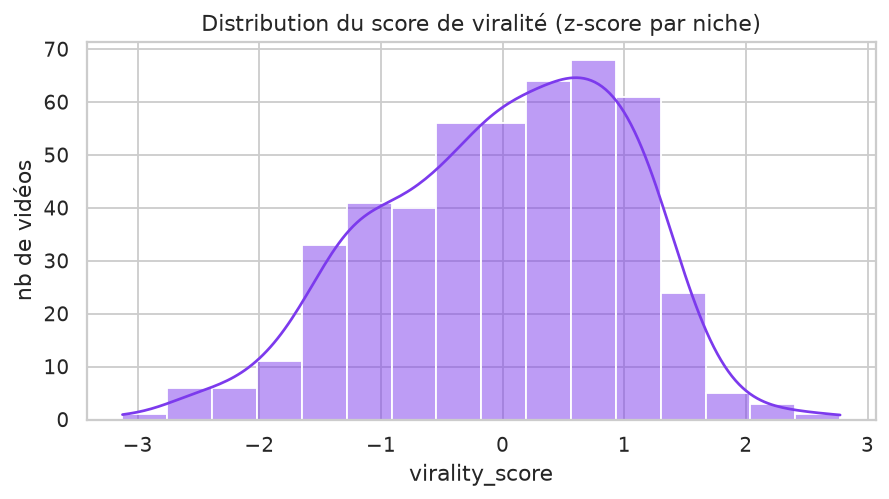

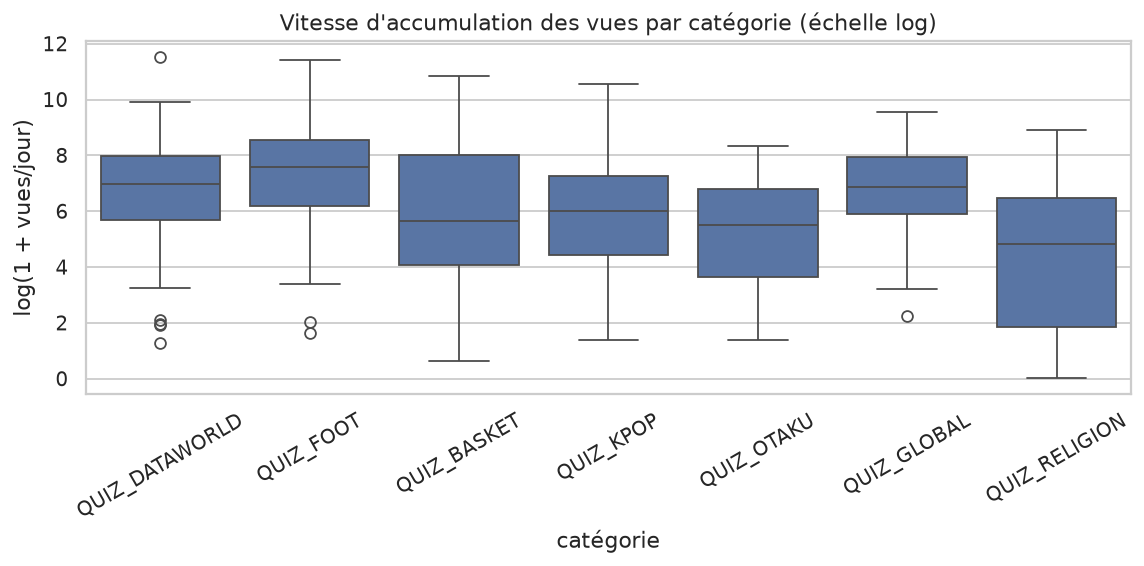

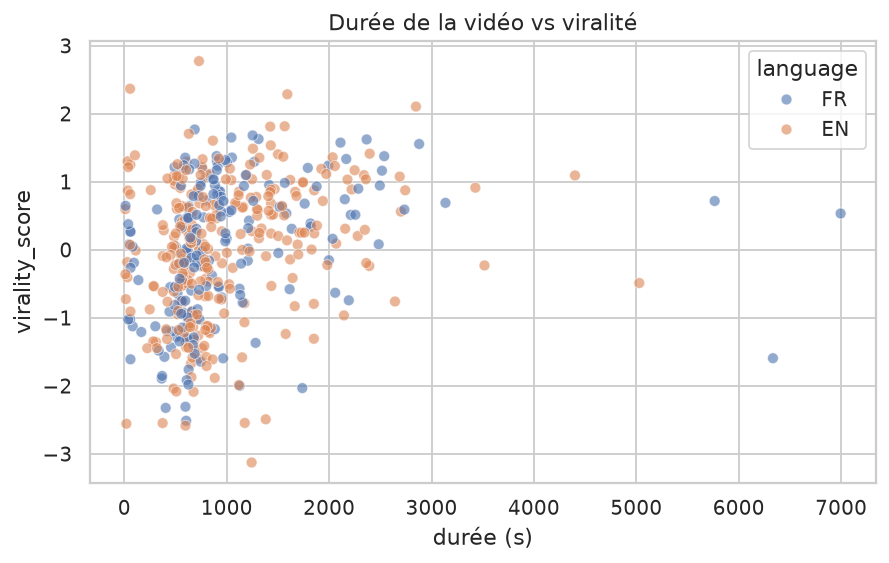

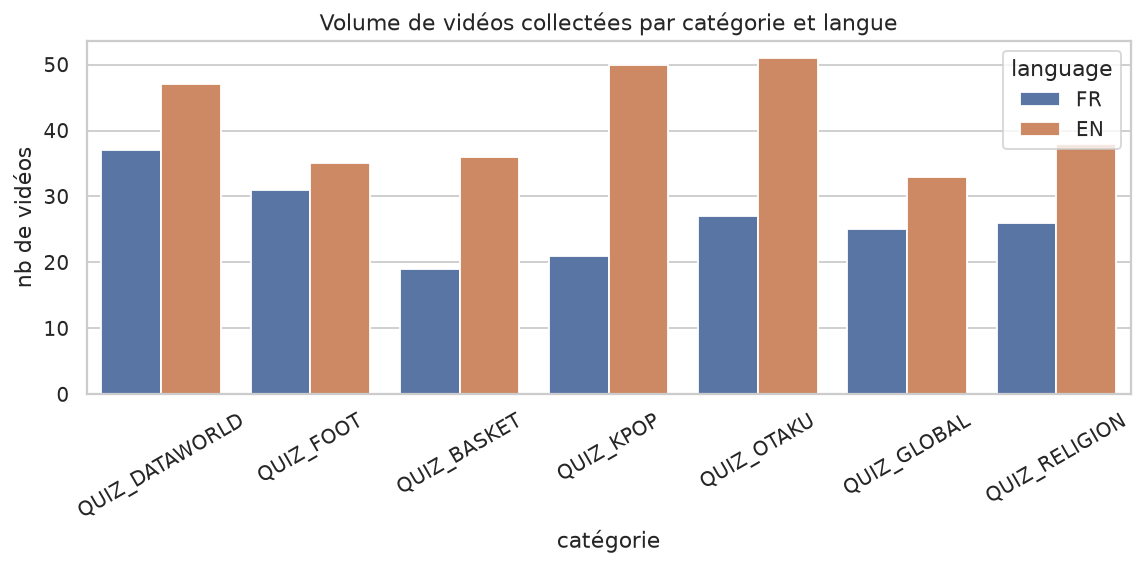

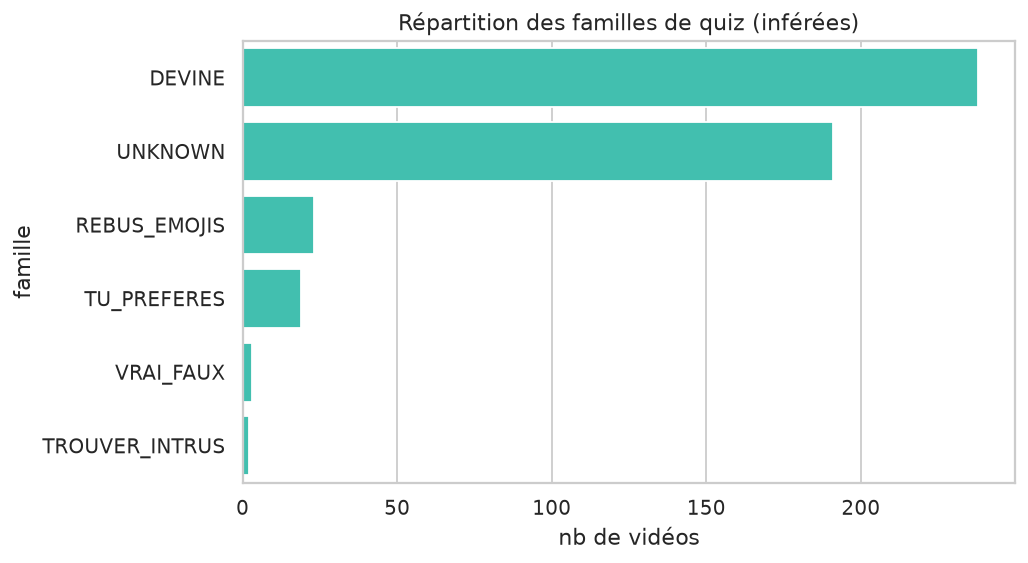

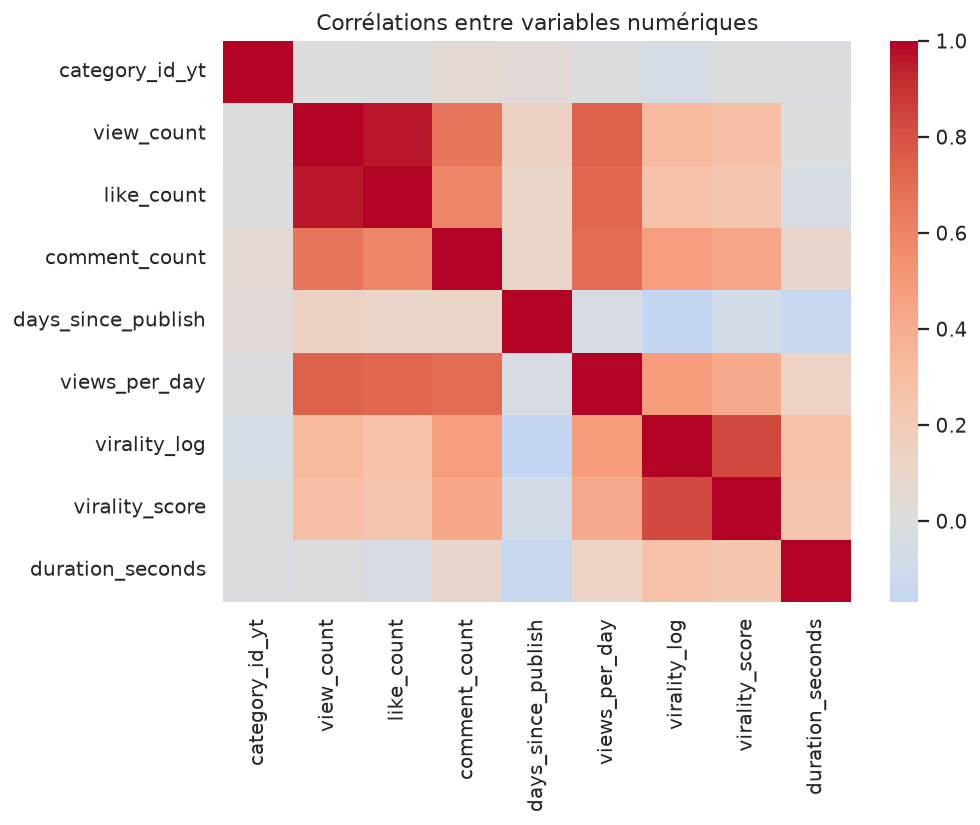

In [4]:
paths = eda.generate_all(df)   # génère les PNG dans reports/figures/
for p in paths:
    display(Image(str(p)))

## 4. Validation statistique

Chaque constat visuel est confirmé par un test.

In [5]:
# (a) Différence entre catégories sur views/jour -> Kruskal-Wallis
groups = [g['views_per_day'].values for _, g in df.groupby('category')]
h, p = stats.kruskal(*groups)
print(f'Kruskal-Wallis (catégories) : H={h:.1f}, p={p:.2e}')

# (b) Durée vs viralité -> Spearman
d = df.dropna(subset=['duration_seconds', 'virality_score'])
rho, p2 = stats.spearmanr(d['duration_seconds'], d['virality_score'])
print(f'Spearman durée~viralité      : rho={rho:.3f}, p={p2:.2e}')

# (c) FR vs EN sur views/jour -> Mann-Whitney
fr = df[df.language == 'FR']['views_per_day']; en = df[df.language == 'EN']['views_per_day']
u, p3 = stats.mannwhitneyu(fr, en, alternative='two-sided')
print(f'Mann-Whitney FR vs EN       : médianes FR={fr.median():.0f} EN={en.median():.0f}, p={p3:.2e}')

Kruskal-Wallis (catégories) : H=79.8, p=3.87e-15
Spearman durée~viralité      : rho=0.336, p=4.76e-14
Mann-Whitney FR vs EN       : médianes FR=282 EN=813, p=1.80e-08


## 5. Conclusions

- Les catégories diffèrent significativement (Kruskal-Wallis) → la cible est **normalisée par niche**.
- La **durée** corrèle positivement avec la viralité (Spearman significatif mais modéré, à surveiller pour confondant).
- **Biais de langue** (EN majoritaire) et **40 % de familles manquantes** = limites à documenter.
- → On passe à une **régression** prédisant `virality_score` (notebook 02).